# Analyzing Network Topology

## Initialization: loading the graph

In [1]:
import json
import networkx as nx

# JSON files path
graph_path = "project/file/graph_networkx_15_nodes.json"
traffic_path = "project/file/traffic_15_nodes_net.json"

# Loading the topology
with open(graph_path, "r") as f:
    data = json.load(f)

# Creating the graph in NetworkX
G = nx.Graph()

# Adding nodes with IDs and attributes
for node in data["nodes"]:
    node_id = node["id"]        
    attrs = {k: v for k, v in node.items() if k != "id"} 
    G.add_node(node_id, **attrs)

# Adding edges with attributes
for edge in data["links"]:
    src = edge["source"]
    dst = edge["target"]
    attrs = {k: v for k, v in edge.items() if k not in ["source", "target"]}
    G.add_edge(src, dst, **attrs)

# print("Graph loaded correctly!")
# print(f"Nodes: {G.nodes(data=True)}")
# print(f"Edges: {G.edges(data=True)}")

## Graph Visualization

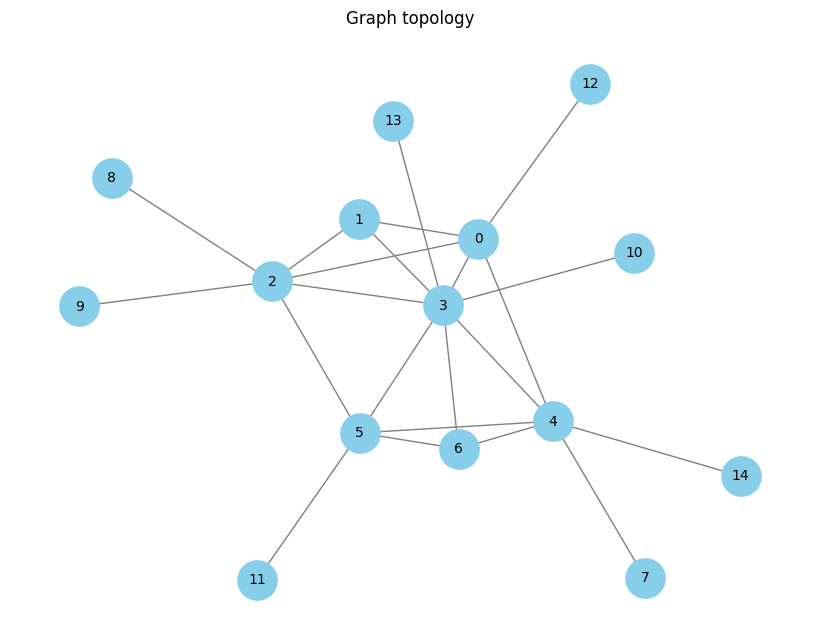

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=True,
    node_size=800,
    node_color="skyblue",
    edge_color="gray",
    font_size=10
)
plt.title("Graph topology")
plt.show()

## Computing Shortest Paths

Computing the shortest paths between all pairs of nodes using Dijkstra.

In [3]:
all_shortest_paths = dict(nx.all_pairs_shortest_path(G))

## Printing Shortest Paths for a specific node

In [4]:
source_node = 14

if source_node in all_shortest_paths:
    print(f"Shortest path from node {source_node}:")
    for target, path in all_shortest_paths[source_node].items():
        if len(path) > 2:
            print(f"  -> {target}: {path}")
else:
    print(f"{source_node} node does not exist in the graph!")

Shortest path from node 14:
  -> 0: [14, 4, 0]
  -> 3: [14, 4, 3]
  -> 5: [14, 4, 5]
  -> 6: [14, 4, 6]
  -> 7: [14, 4, 7]
  -> 1: [14, 4, 0, 1]
  -> 2: [14, 4, 0, 2]
  -> 12: [14, 4, 0, 12]
  -> 10: [14, 4, 3, 10]
  -> 13: [14, 4, 3, 13]
  -> 11: [14, 4, 5, 11]
  -> 8: [14, 4, 0, 2, 8]
  -> 9: [14, 4, 0, 2, 9]


## Computing Centrality on Nodes

In [5]:
node_centrality = nx.betweenness_centrality(G)

print("Centrality values:")
for node, value in node_centrality.items():
    if value != 0.0:
        print(f"{node}: {value:.4f}")

# print(sum(node_centrality.values()))

Centrality values:
0: 0.1923
2: 0.3004
3: 0.3883
4: 0.3004
5: 0.1923


#### Ordering Nodes for Centrality Value (descending order)

In [6]:
sorted_nodes = sorted(node_centrality.items(), key=lambda x: x[1], reverse=True)

print("Nodes ordered for descending centrality:")
for node, value in sorted_nodes:
    if value != 0.0:
        print(f"{node}: {value:.4f}")

Nodes ordered for descending centrality:
3: 0.3883
2: 0.3004
4: 0.3004
0: 0.1923
5: 0.1923


## Highlighting Most Central Nodes

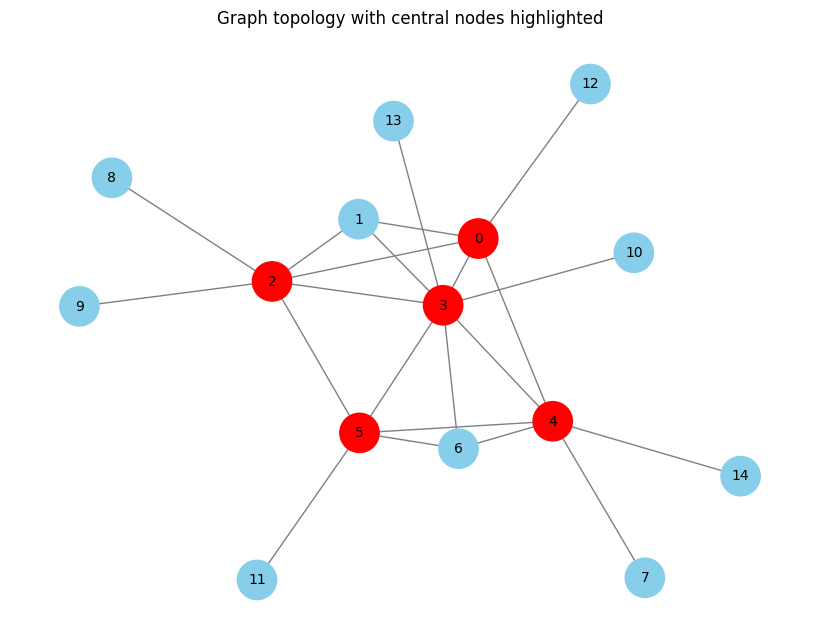

In [7]:
# Central nodes are red coloured
k = 5
central_nodes = set([node for node, _ in sorted_nodes[:k]])
node_colors = ["red" if n in central_nodes else "skyblue" for n in G.nodes()]

plt.figure(figsize=(8,6))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=800,
    node_color=node_colors,
    edge_color="gray",
    font_size=10
)
plt.title("Graph topology with central nodes highlighted")
plt.show()

## Shortest Paths on edge weights with node centrality

We assign edge weights to the graph using node centrality values. Given two nodes $u, v$ we compute the weight on the edge $(u, v)$ as the average of the weights of the two nodes. So we have: $$weight(u, v) = \frac{node\_centr(u) + node\_centr(v)}{2} + 1$$ The $+1$ is necessary to prevent having $0$ as weight value.

In [8]:
# New weighted graph
G_node_weighted = nx.Graph()

for u, v in G.edges():
    # weight = average centrality of the two nodes + 1 to avoid 0 values
    weight = (node_centrality[u] + node_centrality[v]) / 2 + 1
    G_node_weighted.add_edge(u, v, weight=weight)

# Shortest paths computation on weighted graph on single source node
# weighted_paths = nx.single_source_dijkstra_path(G_node_weighted, source_node, weight="weight")

# print(f"Shortest paths from node {source_node} minimizing centrality values:")
# for target, path in weighted_paths.items():
#     if len(path) > 2:
#         print(f"  -> {target}: {path}")

# Shortest paths computation on weighted graph for all nodes
node_centrality_shortest_paths = dict(nx.all_pairs_dijkstra_path(G_node_weighted, weight="weight"))

# print("Shortest paths for all node pairs:")
# for source, targets in node_centrality_shortest_paths.items():
#     for target, path in targets.items():
#         print(f"{source} -> {target}: {path}")

## Computing Centrality on Edges

In [9]:
edge_centrality = nx.edge_betweenness_centrality(G)

# print("Centrality values for edges:")
# for edge, value in edge_centrality.items():
#     print(f"{edge}: {value:.4f}")

## Shortest Paths on edge weights with edge centrality

In [10]:
# New graph weighted on edge centrality values
G_edge_weighted = nx.Graph()

for u, v in G.edges():
    weight = edge_centrality[(u, v)] + 1    # +1 to avoid 0 as centrality value
    G_edge_weighted.add_edge(u, v, weight=weight)

# Computing shortest paths from source node
# shortest_paths_edge_weighted = nx.single_source_dijkstra_path(G_edge_weighted, source_node, weight="weight")

# print(f"\nShortest path from node {source_node} avoiding central edges:")
# for target, path in shortest_paths_edge_weighted.items():
#     if len(path) > 2:
#         print(f"  {source_node} -> {target}: {path}")

edge_centrality_shortest_paths = dict(nx.all_pairs_dijkstra_path(G_edge_weighted, weight="weight"))

## CentFlow Implementation

This is a possible implementation of the CentFlow algorithm described in the article found by the professor. We do not take into account the utilization metrics used in the paper because we are in a static setting, so we only consider the centrality and the degree of the nodes.

Unique path lengths: [1, 2, 3, 4, 5, 6]
Max path length: 6 from source node: 14

{0: 0.7528089887640449,
 1: 0.5056179775280899,
 2: 1.0,
 3: 0.9550561797752809,
 4: 0.9550561797752809,
 5: 0.7752808988764045,
 6: 0.5056179775280899,
 7: 0.3146067415730337,
 8: 0.3146067415730337,
 9: 0.3146067415730337,
 10: 0.3146067415730337,
 11: 0.3146067415730337,
 12: 0.3146067415730337,
 13: 0.3146067415730337,
 14: 0.3146067415730337}

{0: 0.8681318681318682,
 1: 0.31868131868131866,
 2: 1.0,
 3: 1.0,
 4: 0.8681318681318682,
 5: 0.6043956043956044,
 6: 0.31868131868131866,
 7: 0.31868131868131866,
 8: 0.31868131868131866,
 9: 0.31868131868131866,
 10: 0.31868131868131866,
 11: 0.31868131868131866,
 12: 0.31868131868131866,
 13: 0.31868131868131866,
 14: 0.31868131868131866}

{0: 0.8681318681318682,
 1: 0.31868131868131866,
 2: 1.0,
 3: 0.8901098901098901,
 4: 0.9120879120879121,
 5: 0.6703296703296703,
 6: 0.31868131868131866,
 7: 0.31868131868131866,
 8: 0.31868131868131866,
 9: 0.31868131868

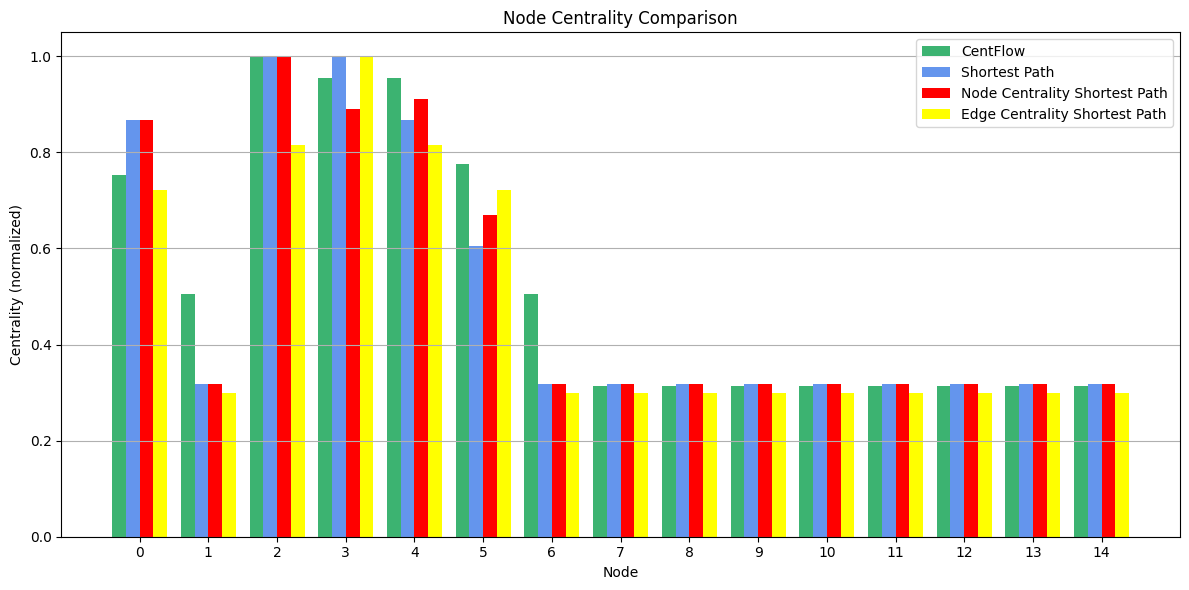

In [17]:
import heapq

with open(traffic_path) as f:
    traffic_data = json.load(f)

# num_nodes = G.number_of_nodes()
# num_edges = G.number_of_edges()
# sample_traffic = list(traffic_data["packets"][:3])
# print(num_nodes)
# print(num_edges)
# print(sample_traffic)

NODE_CAPACITY = 100  # node capacity (same for all nodes)
LINK_CAPACITY = 100  # link capacity (same for all links)
THRESHOLD_NODE = 0.7  # node utilization optional threshold (70%)
THRESHOLD_LINK = 0.5  # node utilization optional threshold (50%)

for u, v in G.edges():
    G[u][v]['capacity'] = LINK_CAPACITY
    G[u][v]['usage'] = 0

for n in G.nodes():
    G.nodes[n]['capacity'] = NODE_CAPACITY
    G.nodes[n]['usage'] = 0


def edge_utilization(u, v):
    return G[u][v]['usage'] / G[u][v]['capacity']


def node_utilization(n):
    return G.nodes[n]['usage'] / G.nodes[n]['capacity']


def effective_degree(node):
    """
    Computes the effective degree discarding saturated edges (above THRESHOLD_LINK)
    or nodes with higher utilization than THRESHOLD_NODE
    """
    if node_utilization(node) >= THRESHOLD_NODE:
        return 0
    neighbors = list(G.neighbors(node))
    return sum(
        1 for nbr in neighbors if edge_utilization(node, nbr) < THRESHOLD_LINK
    )


# Dijkstra modified
def centflow_shortest_path(G, source, target):
    queue = []
    heapq.heappush(queue, (0, source, []))
    visited = set()
    
    while queue:
        cost, node, path = heapq.heappop(queue)
        if node in visited:
            continue
        visited.add(node)
        path = path + [node]
        
        if node == target:
            return path

        for neighbor in G.neighbors(node):
            if neighbor in visited:
                continue

            # weight computation
            e_util = edge_utilization(node, neighbor)
            n_util = node_utilization(neighbor)

            cnb = node_centrality[neighbor]
            ceb = edge_centrality.get((node, neighbor), edge_centrality.get((neighbor, node), 0))
            deg_eff = effective_degree(neighbor)
            node_weight = n_util * cnb * deg_eff
            edge_weight = e_util * ceb
            weight = node_weight + edge_weight + 1e-6

            heapq.heappush(queue, (cost + weight, neighbor, path))
    
    return None  # No path found

# Apply CentFlow to all flows
traffic_paths = {}

# Considering the model of traffic specified in the JSON file
for entry in traffic_data["packets"]:

    # Discard "node" to only consider the numbers
    src = int(entry["src_node"].replace("node", ""))
    traffic_paths[src] = {}
    for dst_str in entry["dst_node"]:

        # Discard "node" to only consider the numbers
        dst = int(dst_str.replace("node", ""))
        path = centflow_shortest_path(G, src, dst)
        if path:
            traffic_paths[src][dst] = path
            for i in range(len(path) - 1):
                u, v = path[i], path[i + 1]
                G[u][v]['usage'] += 1
            for node in path:
                G.nodes[node]['usage'] += 1


from pprint import pprint
import numpy as np

# pprint(traffic_paths)
# print()


'''
num_paths = sum(len(d) for d in traffic_paths.values())
print(f'Total paths = {num_paths}')

print(f'max = {max}\ni = {index}')

s_node = index
for target, path in traffic_paths[s_node].items():
    print(f"{s_node} -> {target}: {path}")
'''


def compute_flow_based_centrality(G, paths):
    centrality = {node: 0 for node in G.nodes()}
    for src, dst_paths in paths.items():
        for dst, path in dst_paths.items():
            for node in path:
                centrality[node] += 1
    # Normalize by max (optional)
    max_cent = 1
    for node in centrality:
        if centrality[node] > max_cent:
            max_cent = centrality[node]

    for node in centrality:
        centrality[node] /= max_cent
    return centrality


def plot_centrality_bar(centrality, title="Flow-Based Centrality"):
    nodes = list(centrality.keys())
    values = list(centrality.values())

    plt.figure(figsize=(10, 6))
    plt.bar([str(n) for n in nodes], values, color="mediumseagreen")
    plt.xlabel("Node")
    plt.ylabel("Centrality (normalized)")
    plt.title(title)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


lengths = set()
max_path_length = -1
index = -1

for s_node in range(15):
    for target, path in traffic_paths[s_node].items():
        path_len = len(path) -1 
        lengths.add(path_len)
        if path_len > max_path_length:
            max_path_length = path_len
            index = s_node

print("Unique path lengths:", sorted(lengths))
print("Max path length:", max_path_length, "from source node:", index)

shortest_centrality = compute_flow_based_centrality(G, all_shortest_paths)
centflow_centrality = compute_flow_based_centrality(G, traffic_paths)
node_shortest_centrality = compute_flow_based_centrality(G, node_centrality_shortest_paths)
edge_shortest_centrality = compute_flow_based_centrality(G, edge_centrality_shortest_paths)

print()
pprint(centflow_centrality)
print()
pprint(shortest_centrality)
print()
pprint(node_shortest_centrality)
print()
pprint(edge_shortest_centrality)
print()

# plot_centrality_bar(centflow_centrality, title="CentFlow-Based Centrality")
# plot_centrality_bar(shortest_centrality, title="Shortest Path Centrality")

def plot_two_centralities(centrality1, centrality2, centrality3, centrality4, labels=("CentFlow", "Shortest")):
    nodes = sorted(centrality1.keys())  # assume both dicts have the same nodes
    values1 = [centrality1[n] for n in nodes]
    values2 = [centrality2[n] for n in nodes]
    values3 = [centrality3[n] for n in nodes]
    values4 = [centrality4[n] for n in nodes]

    x = np.arange(len(nodes))  # positions for the nodes
    width = 0.20  # width of the bars

    plt.figure(figsize=(12, 6))
    plt.bar(x - 1.5*width, values1, width, label=labels[0], color="mediumseagreen")
    plt.bar(x - 0.5*width, values2, width, label=labels[1], color="cornflowerblue")
    plt.bar(x + 0.5*width, values3, width, label=labels[2], color="red")
    plt.bar(x + 1.5*width, values4, width, label=labels[3], color="yellow")

    plt.xticks(x, [str(n) for n in nodes])
    plt.xlabel("Node")
    plt.ylabel("Centrality (normalized)")
    plt.title("Node Centrality Comparison")
    plt.legend()
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

# Usage:
plot_two_centralities(centflow_centrality, shortest_centrality, node_shortest_centrality, edge_shortest_centrality, 
                    labels=("CentFlow", "Shortest Path", "Node Centrality Shortest Path", "Edge Centrality Shortest Path"))
